In [ ]:
%pip install 'qiskit[visualization]'
%pip install qiskit-ibm-runtime

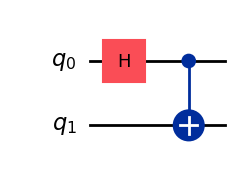

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorOptions
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from matplotlib import pyplot as plt
# Uncomment the next line if you want to use a simulator:
# from qiskit_ibm_runtime.fake_provider import FakeBelemV2


# Create a new circuit with two qubits
qc = QuantumCircuit(2)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

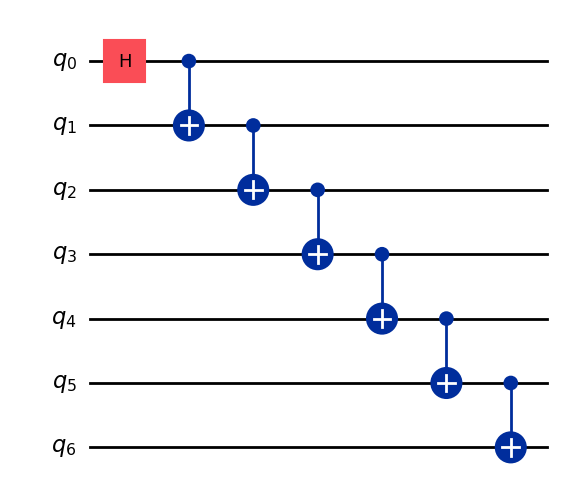

In [ ]:
def get_qc_for_n_qubit_GHZ_state(n: int) -> QuantumCircuit:
    """This function will create a qiskit.QuantumCircuit (qc) for an n-qubit GHZ state.

    Args:
        n (int): Number of qubits in the n-qubit GHZ state

    Returns:
        QuantumCircuit: Quantum circuit that generate the n-qubit GHZ state, assuming all qubits start in the 0 state
    """
    if isinstance(n, int) and n >= 2:
        qc = QuantumCircuit(n)
        qc.h(0)
        for i in range(n - 1):
            qc.cx(i, i + 1)
    else:
        raise Exception("n is not a valid input")
    return qc


# Create a new circuit with 100 qubits in the GHZ state
n = 7
qc = get_qc_for_n_qubit_GHZ_state(n)
qc.draw("mpl")

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_ibm_runtime import EstimatorV2 as Estimator
import numpy as np
import matplotlib.pyplot as plt
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2  # Correct import path

qreg_q = QuantumRegister(2, 'q')
creg_c = ClassicalRegister(1, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

circuit.x(qreg_q[1])
circuit.barrier(qreg_q[0], qreg_q[1])
circuit.h(qreg_q[0])
circuit.h(qreg_q[1])

# U_f
f = int(input("Which function do you want: "))
circuit.barrier(qreg_q[0], qreg_q[1])
circuit.x(qreg_q[0]) if f==3 else None
circuit.cx(qreg_q[0], qreg_q[1]) if f in [2,3] else None
circuit.x(qreg_q[f-3]) if f>=3 else None
circuit.barrier(qreg_q[0], qreg_q[1])

circuit.h(qreg_q[0])
circuit.measure(qreg_q[0], creg_c[0])

# Backend setup for simulation (Fake Backend)
backend = FakeAlmadenV2()
job = backend.run(circuit)
result = job.result()

result_counts = result.get_counts(circuit)
observed_1 = result_counts.get('1', 0)
observed_0 = result_counts.get('0', 0)

# Plotting
x = np.array([0, 1])
counts = [observed_0, observed_1]
bar_width = 0.5

plt.bar(x, counts, width=bar_width, alpha=0.7)
plt.xticks(x, ['0', '1'])
plt.xlabel("Measured Value")
plt.ylabel("Counts")
plt.title("Measurement Counts")
plt.tight_layout()
plt.show()

if observed_0 > observed_1:
    print("Constant")
elif observed_0 < observed_1:
    print("Balanced")

circuit.draw("mpl")

Which function do you want: 5


IndexError: index out of range

Enter number of qubits: 5


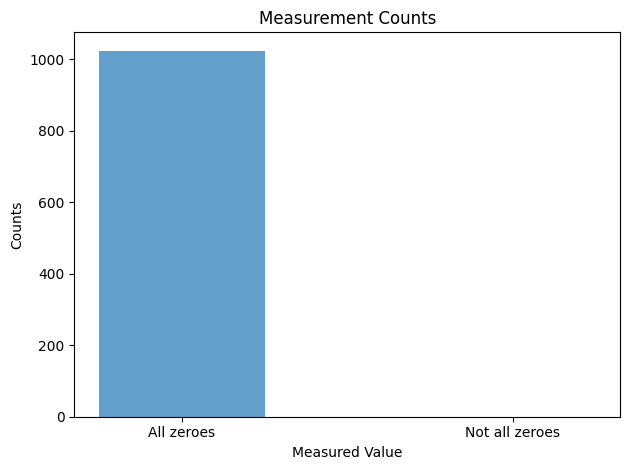

Constant


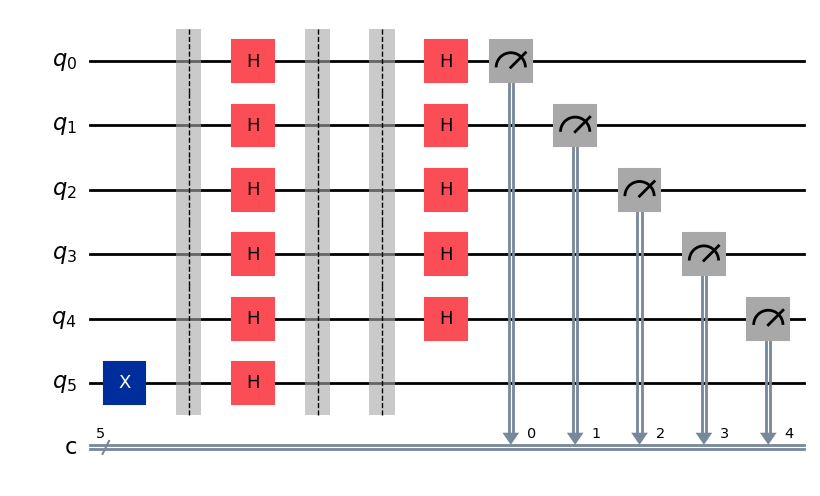

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_ibm_runtime import EstimatorV2 as Estimator
import numpy as np
import matplotlib.pyplot as plt
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2  # Correct import path
import re

n = int(input("Enter number of qubits: "))

qreg_q = QuantumRegister(n+1, 'q')
creg_c = ClassicalRegister(n, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

circuit.x(qreg_q[n])
circuit.barrier()

for i in range(0,n+1):
  circuit.h(qreg_q[i])

# U_f
circuit.barrier()
circuit.barrier()
#circuit.h(qreg_q[0])


for i in range(0,n):
  circuit.h(qreg_q[i])


for i in range(0,n):
  circuit.measure(qreg_q[i], creg_c[i])

# Backend setup for simulation (Fake Backend)
backend = FakeAlmadenV2()
job = backend.run(circuit)
result = job.result()

result_counts = result.get_counts(circuit)

all='0'*n
observed_0 = result_counts.get('0'*n, 0)
observed_1 = sum(counts)-observed_0

# Plotting
x = np.array([0, 1])
counts = [observed_0, observed_1]
bar_width = 0.5

plt.bar(x, counts, width=bar_width, alpha=0.7)
plt.xticks(x, ['All zeroes', 'Not all zeroes'])
plt.xlabel("Measured Value")
plt.ylabel("Counts")
plt.title("Measurement Counts")
plt.tight_layout()
plt.show()

if observed_0 > observed_1:
    print("Constant")
elif observed_0 < observed_1:
    print("Balanced")

circuit.draw("mpl")